<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_10_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red neuronal

Típicamente, una red neuronal artificial consiste en un conjunto de $N$ unidades de procesamiento o "neuronas" que se interconectan entre si vía una matríz de interacciones "sinápticas" $w\in \mathbb{R}^{n\times n}$.
Más precisamente, el estado $x_i$ de la $i$-esima neurona se actualiza según

$$
x_i(t+1) = g\bigg(\sum_j w_{ij}x_j(t) - u_i\bigg) \;\;\;\;\;\;\;\;(1)
$$

Aquí, la función $g:\mathbb{R}\to \mathbb{R}$ es la misma para toda neurona, y se evalúa en términos de una suma pesada sobre el estado de todas las otras neuronas al tiempo anterior $t$, más un término umbral $u_i\in \mathbb{R}$,

$$
h_i(t) = \sum_j w_{ij}x_j(t) - u_i
$$

que se denomina campo local asociado a la neurona $i$.
La entrada $w_{ij}$ de la matriz $w$ corresponde a la conección sináptica que va desde la neurona $j$ hacia la neurona $i$; es decir, regula el flujo de información desde $j$ hacia $i$.

La actualización del estado de las neuronas puede ser sincrónico (todas actualizan su estado simultaneamente) o asincrónico (las neuronas actualizan su estado de a una a la vez y en orden típicamente aleatorio).

El conjunto de neuronas suele dividirse en 3 subconjuntos: el de entrada $E$, el de salida $S$ y el oculto $O$.
En este caso, el estado de las neuronas de entrada no se determina por la ecuación $(1)$, sinó que externamente a travéz de un *input*.
La red se entrena utilizando un conjunto de ejemplos, cada uno constituido por una *entrada* y una *salida* correspondiente.
Sea $e_{ki}$ el valor de la $i$-esima entrada del $k$-ésimo y $s_{ki}$ el valor de la $i$-ésima salida en el $k$-ésimo ejemplo.
De esta manera, el $k$-ésimo ejemplo viene dado por el par $(e_k,s_k)$ de vectores $e_k$ y $s_k$.

Para que aprenda del $k$-ésimo ejemplo, se compara la salida $s_k$ del $k$-ésimo ejemplo, contra la salida correspondiente $x(e_k)$ generada por la red ante la $k$-ésima entrada $e_k$.
Luego, se reajustan los pesos sinápticos $w$ y los umbrales $u$, con la esperanza de reducir las "diferencias" entre la salida esperade y la salida generada.
Este proceso suele repetirse, varias veces sobre cada ejemplo (típicamente elegidos secuencialmente de manera aleatoria), hasta que las "diferencias" entre salidas esperadas y salidas generadas se reducen a un valor aceptable según algún criterio a definir.

## Red feed-forward

En una red feed forward, las neuronas se organizan en capas.
Las neuronas de entrada constituyen la primera capa, que en realidad no se suele contar, o se la denomina capa $0$, ya que las mismas se pueden representar por meras variables.
Luego, pueden seguir varias capas de neuronas ocultas, y finalmente una capa de neuronas de salida que siempre existe, totalizando $1+L$ capas, incluyendo la de entrada $l=0$ y la de salida $l=1+L$.
En este tipo de redes neuronales, las neuronas de una capa sólo reciben conecciones sinápticas de capas anteriores, y típicamente sólo desde la capa anterior.
Por ende, la matriz de conecciones sinápticas $w$ suele remplazarse por una serie de matrices $w_l$, donde la entrada $(w_l)_{ij}$ corresponde a la conección sináptica que va desde la neurona $j$ en la capa $l$ hacia la neurona $i$ en la capa $l+1$.

Como ejemplo, a continuación se esquematiza una red neuronal de dos capas, una oculta y una de salida. Posee 3 neuronas de entradas, 4 neuronas en la capa oculta y 2 neuronas en la capa de salida.
Identificaremos el estado de la $i$-ésima neurona en la $l$-ésima capa con la variable $x_{li}$.
Además, notar que con el fin de remplazar los umbrales $u_{li}$ por correspondientes conecciones sinápticas $(w_l)_{i0}$, se agregan "neuronas fijas" (las de color rosado e indexadas por $i=0$) que, por definición, permanecen siempre en el estado $x_{l0}=-1$.

<img src="https://github.com/jipphysics/redes-neuronales-2023/blob/main/assets/red-feed-forward.png?raw=true:, width=100" alt="My Image" width=300>

## Perceptrón simple

El perceptrón simple es una red feed-forward de una sola capa, i.e. no posee capas ocultas.

### Referencias

* Introduction to the theory of neural computations, J. Hertz, H. Krogh, R.G. Palmer, CRC Press (1991)

## **Ejercicio 1)** Importando librerías

Importe las librerías `numpy` para operar con arrays, `scipy` para utilizar rutinas de algebra lineal y `matplotlib.pyplot` para graficar.

In [ ]:
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import matplotlib.pyplot as plt

## **Ejercicio 2)**

Consideremos el caso de un perceptrón simple con una única neurona de salida y la función signo como función activación (sección 5.2 del Hertz)

$$
g(h)
=
\left\{
\begin{array}{ll}
1 & h > 0 \\
-1 & c.c.
\end{array}
\right.
$$

**a)** Importe la función `make_classification` de scikit-learn para generar un conjunto de ejemplos a aprender. Para ello, escriba

    from sklearn.datasets import make_classification

**b)** Genere un conjunto de 10 ejemplos (`n_samples=10`). Las entradas deben ser vectores con dos coordenadas (`n_features=2`). Las salidas deben poseer dos valores (`n_classes=2`). Notar que `make_classification` genera salidas con valores en $\{0,1\}$, use la función $v\to 2v-1$ para transformarlos a valores en $\{-1,1\}$.

**c)** Grafique los ejemplos en el plano.

**d)** Implemente un perceptrón simple de 2 entradas + 1 neurona fija, y una salida. Entrene la red utilizando la regla (ver ec. 5.23 del Hertz)

$$
\Delta w_{i} = \eta \Theta\bigg(\epsilon-s_kh_k\bigg)s_ke_{ki}
$$

iterando sequencialmente sobre los ejemlos de entrenamiento.
Aquí, $s_k$ es la única componente de la salida del $k$-ésimo ejemplo, $e_{ki}$ es la $i$-ésima componente de la entrada del $k$-ésimo ejemplo,

$$
h_k
=
\sum_{i=0}^N w_ie_{ki}
$$

es el campo local asociado a la única neurona de salida cuando la red es evaluada en la entrada del $k$-ésimo ejemplo.
Además, $\eta>0$ y $\epsilon>0$ son parámetros pequeños que controlan la convergencia del proceso de entrenamiento y

$$
\Theta(x)
=
\left\{
\begin{array}{ll}
1 & x>0\\
0 & c.c.
\end{array}
\right.
$$

es la función escalón de Heaviside.

**e)** Repitiendo **c)**, grafique la separatriz definida por $y(x) = -w_1/w_2\,x+w_0/w_2$.

In [ ]:
# 2.a)
from sklearn.datasets import make_classification

In [ ]:
# 2.b)

n = 2 # entradas
m = 1 # salidas
q = 10 # el numero de ejemplos

num_classes = 2**m # las salidas deben poseer 2 valores

e,s = make_classification(
    n_samples=q,
    n_features=n,
    n_classes=num_classes,
    n_redundant=0,
    n_clusters_per_class=1
)
# arriba defini los valores de entrada y de salida de los ejemplos.
# me da q ejemplos, con n caracteristicas (entradas), num_classes salidas (clases de la clasificación), sin redundancia en las características.
# y hay 1 cluster por clase

s = 2*s-1 # transformo las salidas en valores -1 o 1
e, s

(array([[-1.28620289,  1.68494574],
        [-0.87987199,  0.94438257],
        [-2.01930121,  2.79002453],
        [-0.52641324, -1.68853625],
        [-0.74943077, -1.85023828],
        [-0.02662501, -0.76763411],
        [-2.77854478,  0.67732667],
        [-1.04909595, -0.35586572],
        [-1.57255125,  1.96570431],
        [-0.13379992, -1.75674851]]),
 array([ 1,  1,  1, -1, -1,  1, -1, -1,  1, -1]))

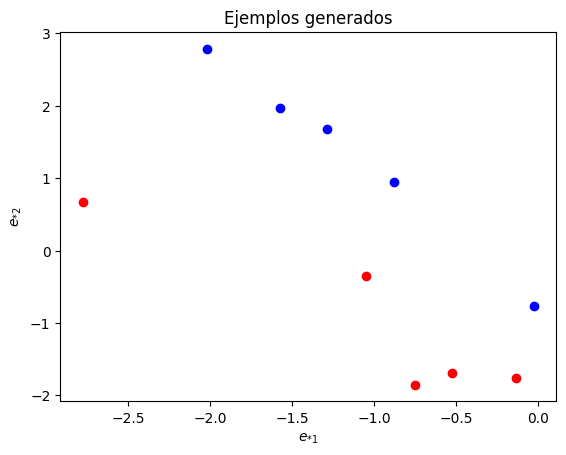

In [ ]:
# 2.c)

# grafiquemos en el plano e1 vs e2

color = {-1:'red',1:'blue'} # si la salida es -1 entonces rojo, si es 1 entonces azul
for k in range(q): # para todos los ejemplos
    plt.scatter([e[k,0]],[e[k,1]],c=color[s[k]]) # ploteo el valor de la primera entrada vs el de la segunda con el color correspondiente a su salida
plt.title("Ejemplos generados")
plt.xlabel("$e_{*1}$")
plt.ylabel("$e_{*2}$")
plt.show()

In [ ]:
# 2.d)

# extendemos las entradas agragando el valor del umbral que vale siempre -1
umbral = -np.ones((q,1+n)) # 3 columnas todas con -1, la 2 y 3 columna la vamos a redefinir
umbral

array([[-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.],
       [-1., -1., -1.]])

In [ ]:
entradas = umbral
entradas[:,1] = e[:, 0]
entradas[:,2] = e[:, 1]
entradas

array([[-1.        , -1.28620289,  1.68494574],
       [-1.        , -0.87987199,  0.94438257],
       [-1.        , -2.01930121,  2.79002453],
       [-1.        , -0.52641324, -1.68853625],
       [-1.        , -0.74943077, -1.85023828],
       [-1.        , -0.02662501, -0.76763411],
       [-1.        , -2.77854478,  0.67732667],
       [-1.        , -1.04909595, -0.35586572],
       [-1.        , -1.57255125,  1.96570431],
       [-1.        , -0.13379992, -1.75674851]])

In [ ]:
# vamos entonces a entrenar a la red usando la ecuación de arriba
# para eso necesitamos la función heaviside

def heaviside(x):
  if x>0:
    return 1
  else:
    return 0

In [ ]:
# primero generamos un w al azar
w = np.random.random(1+n) # me da valores random entre 0 y 1, n+1 (entradas y umbral)

# elijo eta y epsilon
eta = 0.1
eps = 0.1

for epoca in range(0, 100): # hago 100 entrenamientos
  for k in range(0, q): # vemos todos los ejemplos
    h=0
    for i in range(0, n+1):
      h = h + w[i]*entradas[k,i] # armo la suma ponderada, esto podría hacerse con un dot
    for j in range(0, n+1): # para cada entrada, veo delta y cambio w de cada entrada
      delta = eta*heaviside(eps-s[k]*h)*s[k]*entradas[k, j]
      w[j] = w[j] + delta

In [ ]:
w

array([-0.46788557,  0.45636926,  0.3762737 ])

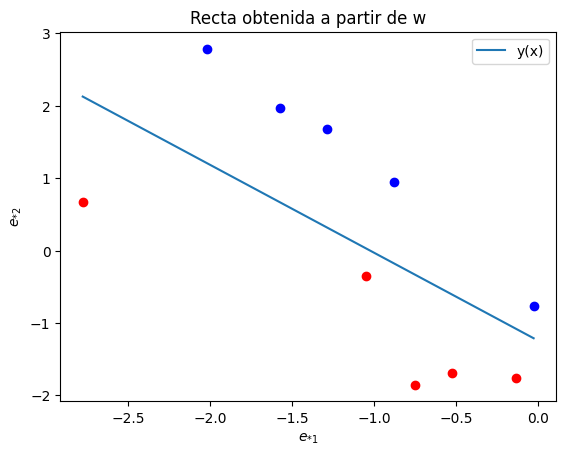

In [ ]:
# 2.e)

# y=-w1/w2 x + w0/w2

a = min(e[:,0])
b = max(e[:,0])

valores_x = np.linspace(a, b, 100)
valores_y = [-(w[1]/w[2])*x + (w[0]/w[2]) for x in valores_x]

color = {-1:'red',1:'blue'} # si la salida es -1 entonces rojo, si es 1 entonces azul
for k in range(q): # para todos los ejemplos
    plt.scatter([e[k,0]],[e[k,1]],c=color[s[k]]) # ploteo el valor de la primera entrada vs el de la segunda con el color correspondiente a su salida
plt.plot(valores_x, valores_y, label="y(x)")
plt.title("Recta obtenida a partir de w")
plt.xlabel("$e_{*1}$")
plt.ylabel("$e_{*2}$")
plt.legend()
plt.show()


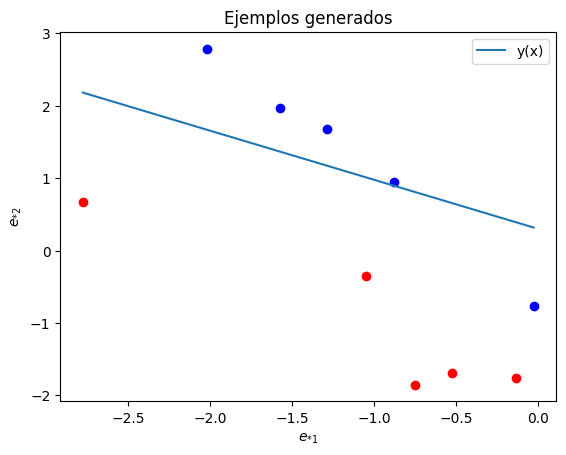

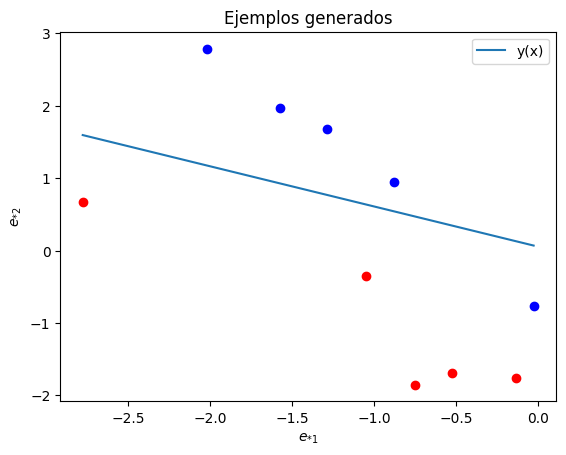

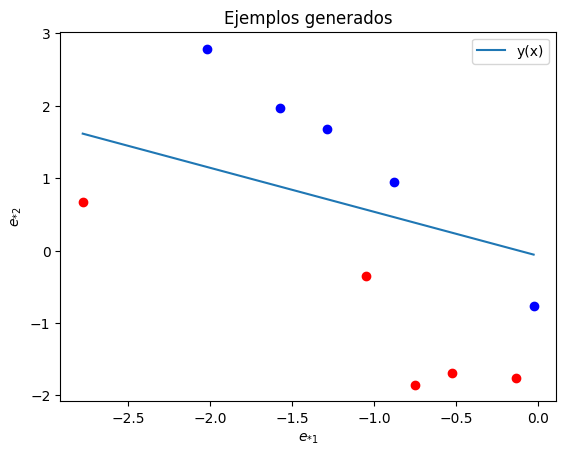

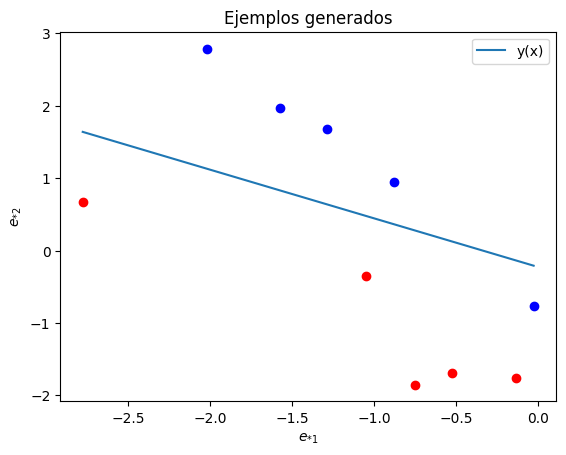

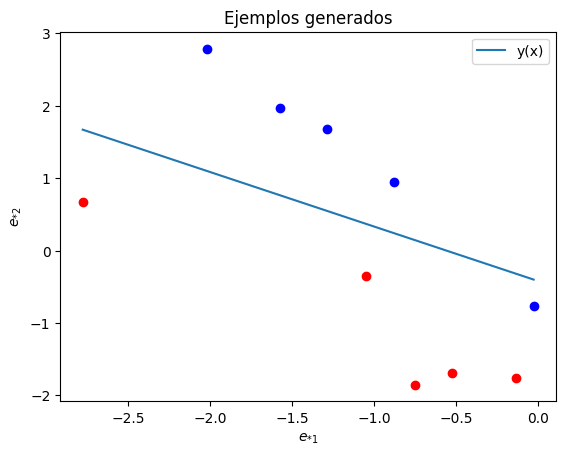

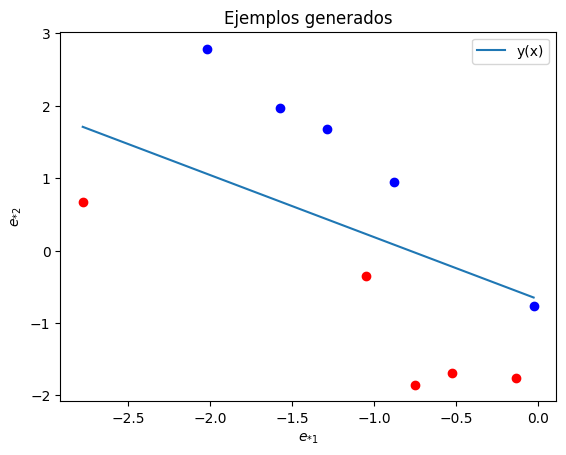

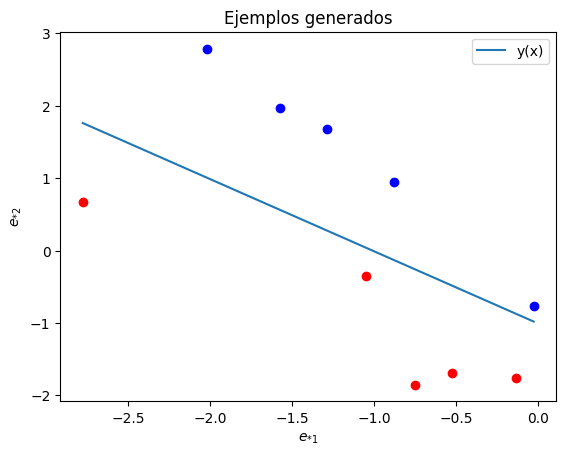

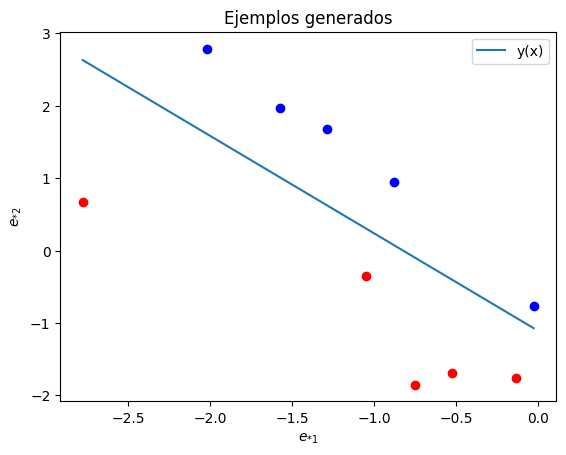

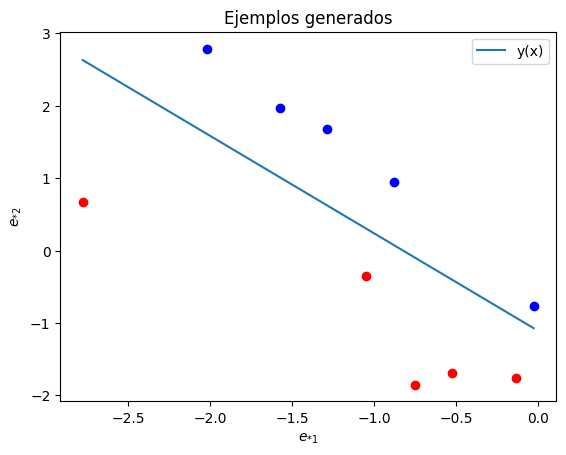

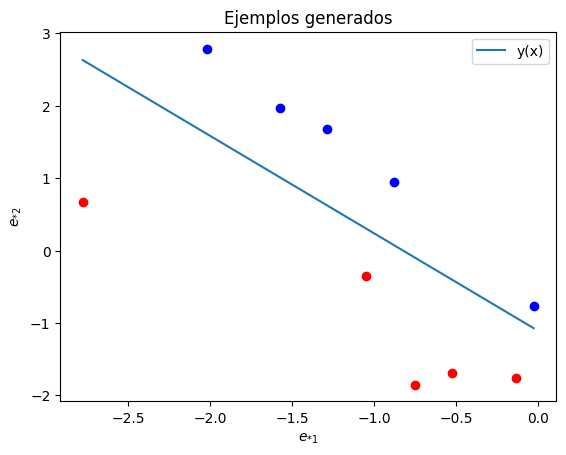

In [ ]:
"""
Aca hacemos lo mismo que antes pero con menos entrenamientos e imprimimos cada paso para ver como va mejorando la cosa
"""
w = np.random.random(1+n) # me da valores random entre 0 y 1, n+1 (entradas y umbral)

# elijo eta y epsilon
eta = 0.1
eps = 0.1

for epoca in range(0, 10): # hago 10 entrenamientos
  for k in range(0, q): # vemos todos los ejemplos
    h=0
    for i in range(0, n+1):
      h = h + w[i]*entradas[k,i] # armo la suma ponderada, esto podría hacerse con un dot
    for j in range(0, n+1): # para cada entrada, veo delta y cambio w de cada entrada
      delta = eta*heaviside(eps-s[k]*h)*s[k]*entradas[k, j]
      w[j] = w[j] + delta


  a = min(e[:,0])
  b = max(e[:,0])

  valores_x = np.linspace(a, b, 100)
  valores_y = [-(w[1]/w[2])*x + (w[0]/w[2]) for x in valores_x]

  color = {-1:'red',1:'blue'} # si la salida es -1 entonces rojo, si es 1 entonces azul
  for k in range(q): # para todos los ejemplos
      plt.scatter([e[k,0]],[e[k,1]],c=color[s[k]]) # ploteo el valor de la primera entrada vs el de la segunda con el color correspondiente a su salida
  plt.plot(valores_x, valores_y, label="y(x)")
  plt.title("Ejemplos generados")
  plt.xlabel("$e_{*1}$")
  plt.ylabel("$e_{*2}$")
  plt.legend()
  plt.show()

## **Ejercicio 3)**

**a)** Realice la animación que les comentó Pancho y gánese un champan.

**b)** Compártalo con los compañeros.

In [ ]:
# 3.a)